In [1]:
#import lib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

In [2]:
survey = pd.read_csv('survey.csv')
survey.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [3]:
print(survey.dtypes)

Timestamp                    object
Age                           int64
Gender                       object
Country                      object
state                        object
self_employed                object
family_history               object
treatment                    object
work_interfere               object
no_employees                 object
remote_work                  object
tech_company                 object
benefits                     object
care_options                 object
wellness_program             object
seek_help                    object
anonymity                    object
leave                        object
mental_health_consequence    object
phys_health_consequence      object
coworkers                    object
supervisor                   object
mental_health_interview      object
phys_health_interview        object
mental_vs_physical           object
obs_consequence              object
comments                     object
dtype: object


In [4]:
#only age has int 
#ignore timestamp, country, state, comments

In [6]:
survey.drop(['Timestamp', 'state', 'comments', 'Country'], axis= 1, inplace= True)

In [10]:
print(survey['Age'].min())
print(survey['Age'].max())

-1726
99999999999


In [11]:
survey['Gender'].value_counts()

Gender
Male                                              615
male                                              206
Female                                            121
M                                                 116
female                                             62
F                                                  38
m                                                  34
f                                                  15
Make                                                4
Male                                                3
Woman                                               3
Cis Male                                            2
Man                                                 2
Female (trans)                                      2
Female                                              2
Trans woman                                         1
msle                                                1
male leaning androgynous                            1
Neuter               

In [13]:
# after finding some weird responses in the age column 
# i decided to only include 'valid' numbers for age
survey['Age'] = survey['Age'].apply(lambda x: x if 0 < x < 100 else np.nan)

In [15]:
# first lower case and strip eveything to decrease options
survey['Gender'] = survey['Gender'].apply(lambda x: x.lower().strip())

In [16]:

male = ['male', 'm', 'make', 'cis male', 'man', 'cis man', 'msle', 'malr', 'mail', 'maile', 'something kinda male?', 'ostensibly male, unsure what that really means', 'male-ish', 'guy (-ish) ^_^', 'mal', 'male (cis)']
female = ['female', 'f', 'woman', 'female (cis)', 'cis-female/femme', 'femake', 'cis female', 'femail']

def regender(gender_input):
    
    """
    Input: a string about gender
    Output: male, female or other depending on our dictionary
    
    """ 
    if gender_input in male:
        return 'male'
    elif gender_input in female:
        return 'female'
    else:
        return 'other'
    
survey['Gender'] = survey['Gender'].apply(regender)


In [18]:
survey.Gender.value_counts(dropna= False)

Gender
male      994
female    247
other      18
Name: count, dtype: int64

In [19]:
print(survey.shape)
survey.head()

(1259, 23)


,Age,Gender,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37.0,female,NaN,No,Yes,Often,6-25,No,Yes,Yes,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,44.0,male,NaN,No,No,Rarely,More than 1000,No,No,Don't know,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,32.0,male,NaN,No,No,Rarely,6-25,No,Yes,No,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,31.0,male,NaN,Yes,Yes,Often,26-100,No,Yes,No,...,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,31.0,male,NaN,No,No,Never,100-500,Yes,Yes,Yes,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No


In [20]:
survey.tail()

,Age,Gender,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
1254,26.0,male,No,No,Yes,NaN,26-100,No,Yes,No,...,Don't know,Somewhat easy,No,No,Some of them,Some of them,No,No,Don't know,No
1255,32.0,male,No,Yes,Yes,Often,26-100,Yes,Yes,Yes,...,Yes,Somewhat difficult,No,No,Some of them,Yes,No,No,Yes,No
1256,34.0,male,No,Yes,Yes,Sometimes,More than 1000,No,Yes,Yes,...,Don't know,Somewhat difficult,Yes,Yes,No,No,No,No,No,No
1257,46.0,female,No,No,No,NaN,100-500,Yes,Yes,No,...,Don't know,Don't know,Yes,No,No,No,No,No,No,No
1258,25.0,male,No,Yes,Yes,Sometimes,26-100,No,No,Yes,...,Yes,Don't know,Maybe,No,Some of them,No,No,No,Don't know,No


In [21]:
survey.isnull().sum()

Age                            5
Gender                         0
self_employed                 18
family_history                 0
treatment                      0
work_interfere               264
no_employees                   0
remote_work                    0
tech_company                   0
benefits                       0
care_options                   0
wellness_program               0
seek_help                      0
anonymity                      0
leave                          0
mental_health_consequence      0
phys_health_consequence        0
coworkers                      0
supervisor                     0
mental_health_interview        0
phys_health_interview          0
mental_vs_physical             0
obs_consequence                0
dtype: int64

In [25]:

survey['self_employed'] = survey['self_employed'].fillna("Don't Know")
survey['work_interfere'] = survey['work_interfere'].fillna("Don't Know")



In [26]:
survey.dropna(subset=['Age'], inplace=True)

In [27]:
survey.isnull().sum()

Age                          0
Gender                       0
self_employed                0
family_history               0
treatment                    0
work_interfere               0
no_employees                 0
remote_work                  0
tech_company                 0
benefits                     0
care_options                 0
wellness_program             0
seek_help                    0
anonymity                    0
leave                        0
mental_health_consequence    0
phys_health_consequence      0
coworkers                    0
supervisor                   0
mental_health_interview      0
phys_health_interview        0
mental_vs_physical           0
obs_consequence              0
dtype: int64

In [31]:
# as observed there are diff values like don't know sometimes ofter rarely we can replace this to don't know for consistency 

possible_answers = {col:[i for i in survey[col].unique()] for col in survey.columns if col not in exclude}
possible_answers

{'Gender': ['female', 'male', 'other'],
 'self_employed': ["Don't Know", 'Yes', 'No'],
 'family_history': ['No', 'Yes'],
 'treatment': ['Yes', 'No'],
 'work_interfere': ['Often', 'Rarely', 'Never', 'Sometimes', "Don't Know"],
 'no_employees': ['6-25',
  'More than 1000',
  '26-100',
  '100-500',
  '1-5',
  '500-1000'],
 'remote_work': ['No', 'Yes'],
 'tech_company': ['Yes', 'No'],
 'benefits': ['Yes', "Don't know", 'No'],
 'care_options': ['Not sure', 'No', 'Yes'],
 'wellness_program': ['No', "Don't know", 'Yes'],
 'seek_help': ['Yes', "Don't know", 'No'],
 'anonymity': ['Yes', "Don't know", 'No'],
 'leave': ['Somewhat easy',
  "Don't know",
  'Somewhat difficult',
  'Very difficult',
  'Very easy'],
 'mental_health_consequence': ['No', 'Maybe', 'Yes'],
 'phys_health_consequence': ['No', 'Yes', 'Maybe'],
 'coworkers': ['Some of them', 'No', 'Yes'],
 'supervisor': ['Yes', 'No', 'Some of them'],
 'mental_health_interview': ['No', 'Yes', 'Maybe'],
 'phys_health_interview': ['Maybe', 'No',

In [32]:
# self employed-replace don't know to no 
#work interfere- never nd don't know to no 
#benefits, seekhelp, anonymity,mental_vs_physical - don't know to no
#all other maybe to no 


In [33]:
survey['self_employed'] = survey['self_employed'].replace("Don't Know", 'No')

In [34]:
survey['work_interfere'] = survey['work_interfere'].replace({
    "Don't Know": 'No',
    'Never': 'No'
})

In [35]:
cols = ['benefits', 'seek_help', 'anonymity', 'mental_vs_physical']
for col in cols:
    survey[col] = survey[col].replace("Don't know", 'No')

In [36]:
for col in survey.columns:
    survey[col] = survey[col].replace('Maybe', 'No')

In [38]:
for col in survey.columns:
    survey[col] = survey[col].replace("Don't know", 'No')

In [40]:
survey['care_options'] = survey['care_options'].replace('Not sure', 'No')

In [42]:
possible_answers = {col:[i for i in survey[col].unique()] for col in survey.columns if col not in exclude}
possible_answers

{'Gender': ['female', 'male', 'other'],
 'self_employed': ['No', 'Yes'],
 'family_history': ['No', 'Yes'],
 'treatment': ['Yes', 'No'],
 'work_interfere': ['Often', 'Rarely', 'No', 'Sometimes'],
 'no_employees': ['6-25',
  'More than 1000',
  '26-100',
  '100-500',
  '1-5',
  '500-1000'],
 'remote_work': ['No', 'Yes'],
 'tech_company': ['Yes', 'No'],
 'benefits': ['Yes', 'No'],
 'care_options': ['No', 'Yes'],
 'wellness_program': ['No', 'Yes'],
 'seek_help': ['Yes', 'No'],
 'anonymity': ['Yes', 'No'],
 'leave': ['Somewhat easy',
  'No',
  'Somewhat difficult',
  'Very difficult',
  'Very easy'],
 'mental_health_consequence': ['No', 'Yes'],
 'phys_health_consequence': ['No', 'Yes'],
 'coworkers': ['Some of them', 'No', 'Yes'],
 'supervisor': ['Yes', 'No', 'Some of them'],
 'mental_health_interview': ['No', 'Yes'],
 'phys_health_interview': ['No', 'Yes'],
 'mental_vs_physical': ['Yes', 'No'],
 'obs_consequence': ['No', 'Yes']}

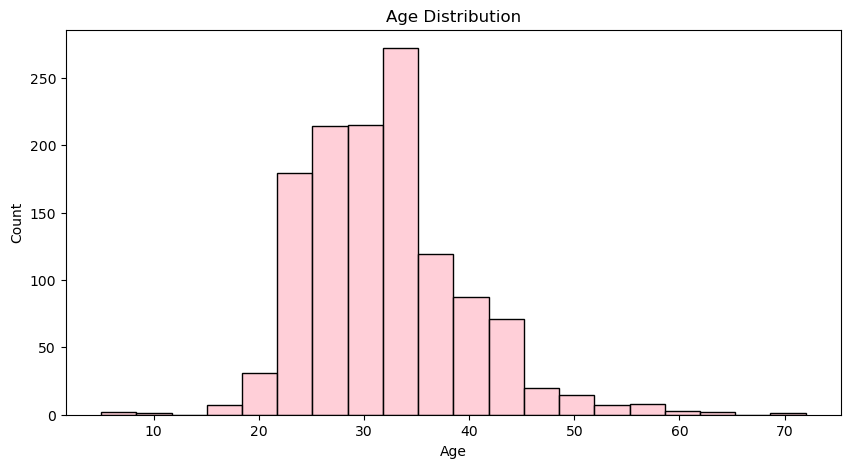

In [44]:
# EDA

plt.figure(figsize=(10,5))
sns.histplot(survey['Age'], bins=20, color='pi')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [74]:

encoding_dict = {
    'No': -1, 
    "Don't know": 0, 
    'Yes': 1,
    'Never': -2, 
    'Rarely': -1, 
    'Sometimes': 1, 
    'Often': 2,
    'Very difficult': -2, 
    'Somewhat difficult': -1, 
    'Somewhat easy': 1, 
    'Some of them' :0,
    'Very easy': 2,
    '1-5': 0, 
    '6-25': 1, 
    '26-100': 2, 
    '100-500': 3, 
    '500-1000': 4, 
    'More than 1000': 5,
    'male': -1, 
    'other': 0, 
    'female': 1
}


In [75]:
# Copy make
survey_coded = survey.copy()

# Age column exclude 
exclude = ['Age']


for col in survey_coded.columns:
    if col not in exclude:
        survey_coded[col] = survey_coded[col].map(encoding_dict)


In [76]:
survey_coded.tail()


,Age,Gender,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
1254,26.0,-1,-1,-1,1,-1,2,-1,1,-1,...,-1,1,-1,-1,0,0,-1,-1,-1,-1
1255,32.0,-1,-1,1,1,2,2,1,1,1,...,1,-1,-1,-1,0,1,-1,-1,1,-1
1256,34.0,-1,-1,1,1,1,5,-1,1,1,...,-1,-1,1,1,-1,-1,-1,-1,-1,-1
1257,46.0,1,-1,-1,-1,-1,3,1,1,-1,...,-1,-1,1,-1,-1,-1,-1,-1,-1,-1
1258,25.0,-1,-1,1,1,1,2,-1,-1,1,...,1,-1,-1,-1,0,-1,-1,-1,-1,-1


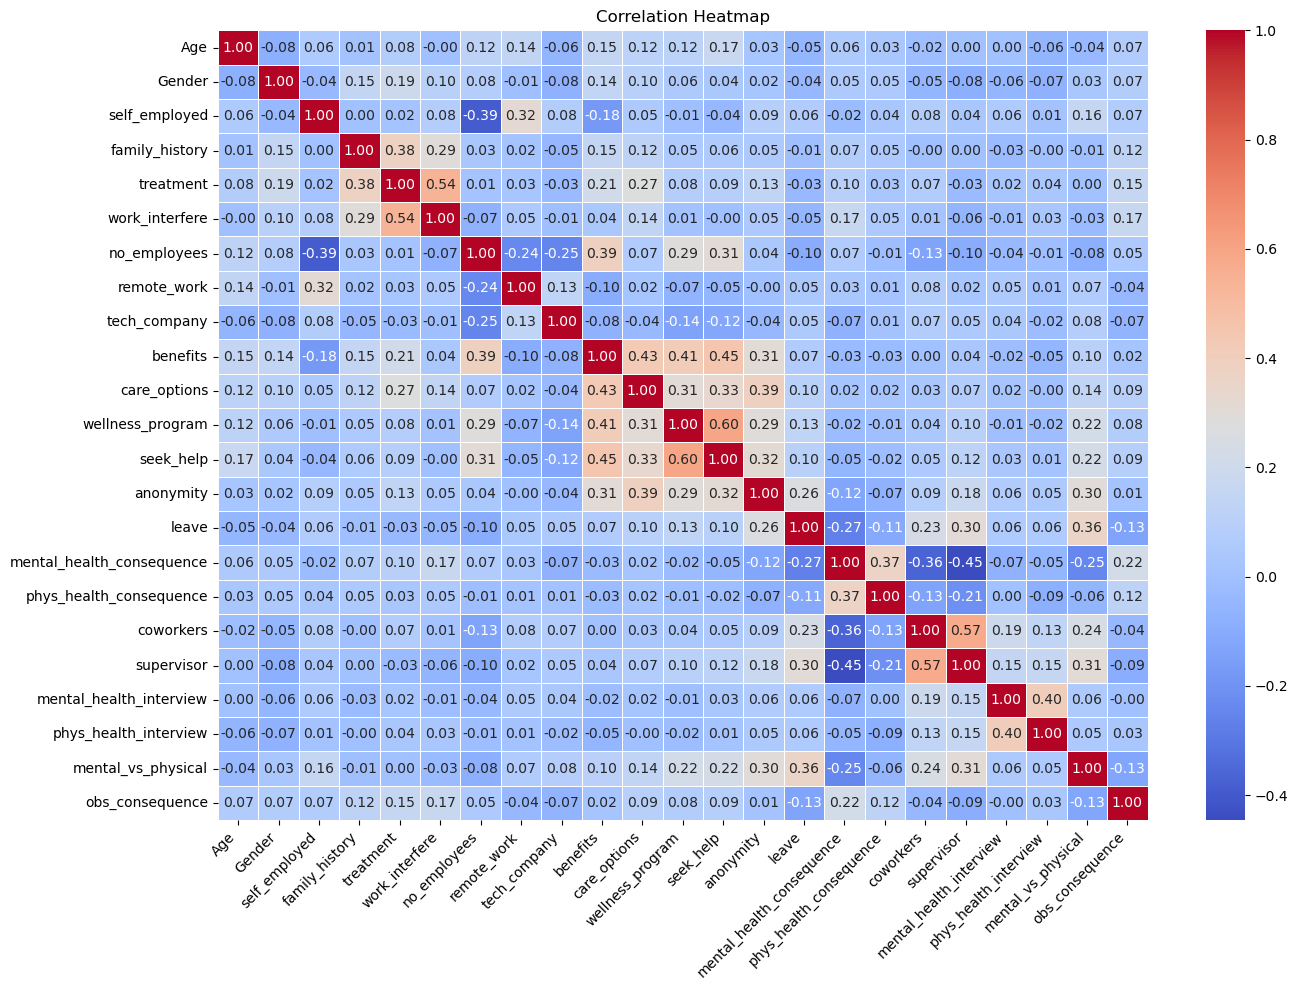

In [77]:
plt.figure(figsize=(14,10))
sns.heatmap(survey_coded.corr(), 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f',
            linewidths=0.5)
plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [79]:

# Treatment percentage
print(survey['treatment'].value_counts(normalize=True) * 100)

# Work interfere percentage  
print(survey['work_interfere'].value_counts(normalize=True) * 100)

# Family history vs treatment (does family history has anything to do with treatment?)
pd.crosstab(survey['family_history'], survey['treatment'], normalize='index') * 100

treatment
Yes    50.478469
No     49.521531
Name: proportion, dtype: float64
work_interfere
No           37.958533
Sometimes    37.001595
Rarely       13.795853
Often        11.244019
Name: proportion, dtype: float64


treatment,No,Yes
family_history,,
No,64.659686,35.340314
Yes,25.918367,74.081633


<Figure size 800x500 with 0 Axes>

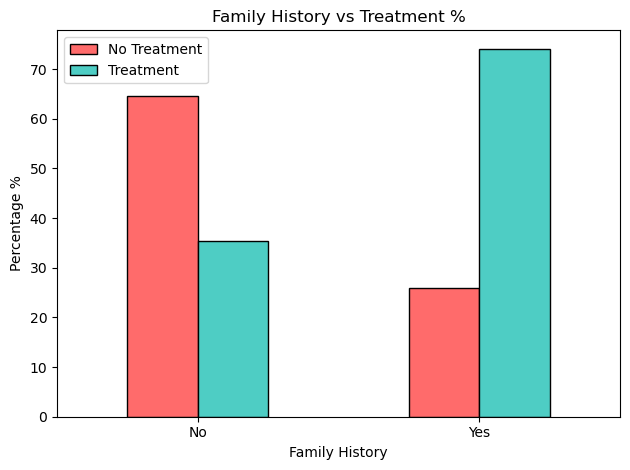

In [81]:
plt.figure(figsize=(8,5))
result1 = pd.crosstab(survey['family_history'], 
                      survey['treatment'], 
                      normalize='index') * 100
result1.plot(kind='bar', color=['#FF6B6B','#4ECDC4'], 
             edgecolor='black')
plt.title('Family History vs Treatment %')
plt.xlabel('Family History')
plt.ylabel('Percentage %')
plt.xticks(rotation=0)
plt.legend(['No Treatment', 'Treatment'])
plt.tight_layout()
plt.show()

In [80]:
# 
result = pd.crosstab(survey['no_employees'], 
                       survey['treatment'], 
                       normalize='index') * 100
print(result)

treatment              No        Yes
no_employees                        
1-5             44.375000  55.625000
100-500         46.022727  53.977273
26-100          48.263889  51.736111
500-1000        55.000000  45.000000
6-25            56.055363  43.944637
More than 1000  48.042705  51.957295
